In [3]:
df.describe()

,index,Qty,Amount,ship-postal-code,New,PendingS
count,128976.000000,128976.000000,121176.000000,128941.000000,0.0,0.0
mean,64486.130427,0.904401,648.562176,463945.677744,NaN,NaN
std,37232.897832,0.313368,281.185041,191458.488954,NaN,NaN
min,0.000000,0.000000,0.000000,110001.000000,NaN,NaN
25%,32242.750000,1.000000,449.000000,382421.000000,NaN,NaN
50%,64486.500000,1.000000,605.000000,500033.000000,NaN,NaN
75%,96730.250000,1.000000,788.000000,600024.000000,NaN,NaN
max,128974.000000,15.000000,5584.000000,989898.000000,NaN,NaN


In [4]:
df.shape

(128976, 21)

In [2]:
from numpy._core.fromnumeric import amax
import pandas as pd
import numpy as np
df=pd.read_csv('Amazon Sale Report.csv')
df.info()
df.head()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128976 entries, 0 to 128975
Data columns (total 21 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128976 non-null  int64  
 1   Order ID            128976 non-null  object 
 2   Date                128976 non-null  object 
 3   Status              128976 non-null  object 
 4   Fulfilment          128976 non-null  object 
 5   Sales Channel       128976 non-null  object 
 6   ship-service-level  128976 non-null  object 
 7   Category            128976 non-null  object 
 8   Size                128976 non-null  object 
 9   Courier Status      128976 non-null  object 
 10  Qty                 128976 non-null  int64  
 11  currency            121176 non-null  object 
 12  Amount              121176 non-null  float64
 13  ship-city           128941 non-null  object 
 14  ship-state          128941 non-null  object 
 15  ship-postal-code    128941 non-nul

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Category,Size,Courier Status,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,B2B,fulfilled-by,New,PendingS
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,T-shirt,S,On the Way,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,False,Easy Ship,NaN,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,Shirt,3XL,Shipped,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,False,Easy Ship,NaN,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,Shirt,XL,Shipped,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,True,NaN,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,Blazzer,L,On the Way,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,False,Easy Ship,NaN,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,Trousers,3XL,Shipped,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,False,NaN,NaN,NaN


In [5]:
df.isnull().sum()

,0
index,0
Order ID,0
Date,0
Status,0
Fulfilment,0
Sales Channel,0
ship-service-level,0
Category,0
Size,0
Courier Status,0


In [6]:
df[df['Amount'].isnull()][['Status','Amount','currency']].head()

,Status,Amount,currency
8,Cancelled,NaN,NaN
29,Cancelled,NaN,NaN
65,Cancelled,NaN,NaN
84,Cancelled,NaN,NaN
95,Cancelled,NaN,NaN


In [7]:
df[df['Amount'].isnull()]['Status'].value_counts()

,count
Status,
Cancelled,7571
Shipped,208
Shipped - Delivered to Buyer,8
Shipping,8
Shipped - Returned to Seller,3
Pending,2


In [8]:
cancelled_orders = df[df['Status'] == 'Cancelled']

cancelled_orders.groupby('Category').size().sort_values(ascending=False)

,0
Category,
T-shirt,7341
Shirt,7254
Blazzer,2123
Trousers,1275
Perfume,145
Wallet,116
Socks,59
Shoes,21


In [9]:
category_cancel_rate = (
    df.assign(Cancelled=df['Status']=='Cancelled')
      .groupby('Category')['Cancelled']
      .mean()*100
)

category_cancel_rate.sort_values(ascending=False)

,Cancelled
Category,
T-shirt,14.596755
Shirt,14.543778
Blazzer,13.696774
Socks,13.409091
Shoes,12.727273
Perfume,12.532411
Wallet,12.526998
Trousers,12.010173
Watch,0.000000


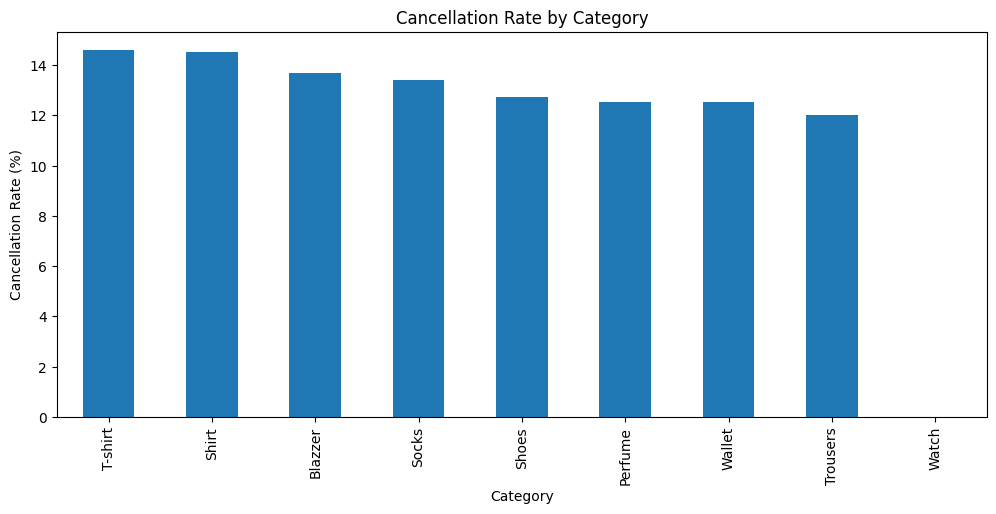

In [10]:
import matplotlib.pyplot as plt

category_cancel_rate.sort_values(ascending=False).plot(
    kind='bar',
    figsize=(12,5)
)

plt.title("Cancellation Rate by Category")
plt.ylabel("Cancellation Rate (%)")
plt.show()

In [11]:
category_revenue = (
    df.groupby('Category')['Amount']
      .sum()
      .sort_values(ascending=False)
)

category_revenue

,Amount
Category,
T-shirt,39206756.65
Shirt,21297770.08
Blazzer,11215104.12
Trousers,5346286.30
Perfume,789419.66
Wallet,458408.18
Socks,150757.50
Shoes,124752.76
Watch,915.00


In [13]:
analysis = pd.DataFrame({
    'Revenue': df.groupby('Category')['Amount'].sum(),
    'Orders': df.groupby('Category').size(),
    'Cancellation_Rate': (
        df.assign(Cancelled=df['Status']=='Cancelled')
          .groupby('Category')['Cancelled']
          .mean()*100
    )
})

analysis.sort_values('Revenue', ascending=False)

,Revenue,Orders,Cancellation_Rate
Category,,,
T-shirt,39206756.65,50292,14.596755
Shirt,21297770.08,49877,14.543778
Blazzer,11215104.12,15500,13.696774
Trousers,5346286.30,10616,12.010173
Perfume,789419.66,1157,12.532411
Wallet,458408.18,926,12.526998
Socks,150757.50,440,13.409091
Shoes,124752.76,165,12.727273
Watch,915.00,3,0.000000


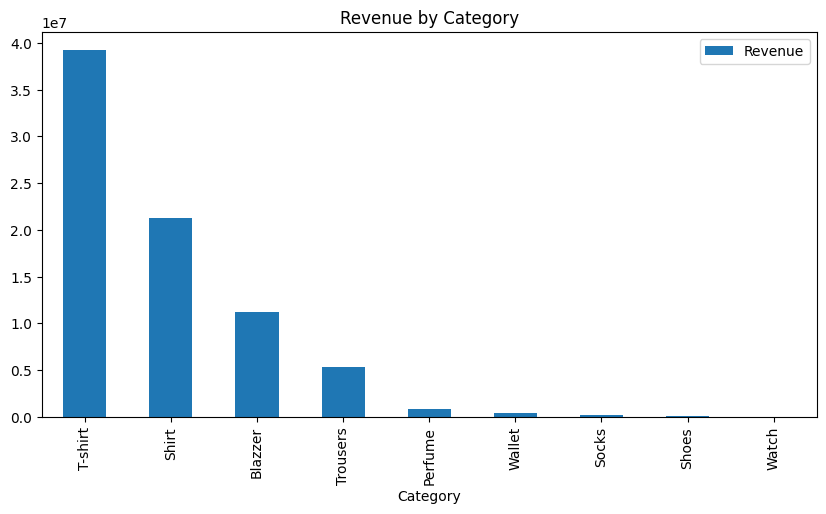

In [14]:
analysis.sort_values('Revenue', ascending=False).plot(
    kind='bar',
    y='Revenue',
    figsize=(10,5)
)
plt.title("Revenue by Category")
plt.show()

In [16]:
state_revenue = (
    df.groupby('ship-state')['Amount']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

state_revenue

,Amount
ship-state,
MAHARASHTRA,13340333.05
KARNATAKA,10480694.22
TELANGANA,6915018.08
UTTAR PRADESH,6823947.08
TAMIL NADU,6519182.30
DELHI,4232738.97
KERALA,3823559.58
WEST BENGAL,3507212.82
ANDHRA PRADESH,3217859.86


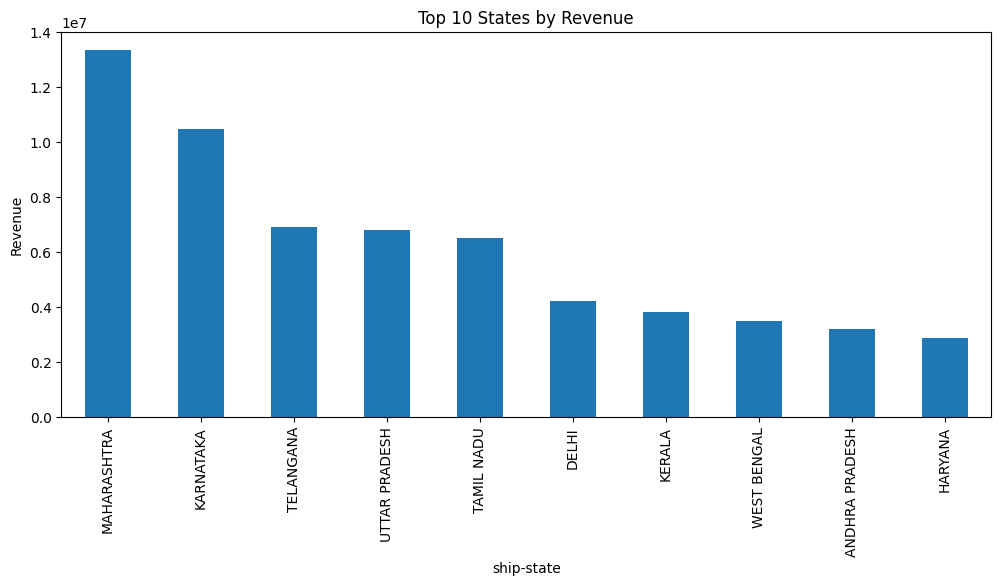

In [17]:
import matplotlib.pyplot as plt

state_revenue.plot(
    kind='bar',
    figsize=(12,5)
)

plt.title("Top 10 States by Revenue")
plt.ylabel("Revenue")
plt.show()

In [18]:
df['Fulfilment'].value_counts()

,count
Fulfilment,
Amazon,89713
Merchant,39263


In [19]:
df.groupby('Fulfilment')['Amount'].sum()

,Amount
Fulfilment,
Amazon,54327540.00
Merchant,24262630.25


In [20]:
fulfillment_cancel_rate = (
    df.assign(Cancelled=df['Status']=='Cancelled')
      .groupby('Fulfilment')['Cancelled']
      .mean()*100
)

fulfillment_cancel_rate

,Cancelled
Fulfilment,
Amazon,12.790788
Merchant,17.469373


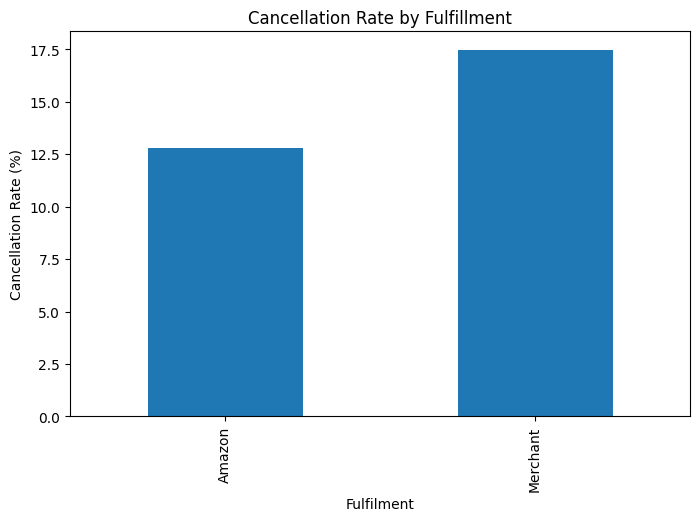

In [21]:
fulfillment_cancel_rate.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Cancellation Rate by Fulfillment")
plt.ylabel("Cancellation Rate (%)")
plt.show()

In [22]:
cancelled_orders = df[df['Status']=='Cancelled']

lost_revenue = cancelled_orders['Amount'].sum()

print(lost_revenue)

6918423.25


In [23]:
cancelled_orders = df[df['Status']=='Cancelled']

lost_revenue = cancelled_orders['Amount'].sum()

print(lost_revenue)

6918423.25


In [24]:
fulfillment_cancel_rate

,Cancelled
Fulfilment,
Amazon,12.790788
Merchant,17.469373


In [25]:
category_summary = pd.DataFrame({
    'Orders': df.groupby('Category').size(),
    'Revenue': df.groupby('Category')['Amount'].sum(),
    'Cancelled_Orders': df[df['Status']=='Cancelled'].groupby('Category').size()
})

category_summary.fillna(0, inplace=True)

category_summary['Cancellation_Rate'] = (
    category_summary['Cancelled_Orders'] /
    category_summary['Orders']
) * 100

category_summary.sort_values(
    'Revenue',
    ascending=False
)

,Orders,Revenue,Cancelled_Orders,Cancellation_Rate
Category,,,,
T-shirt,50292,39206756.65,7341.0,14.596755
Shirt,49877,21297770.08,7254.0,14.543778
Blazzer,15500,11215104.12,2123.0,13.696774
Trousers,10616,5346286.30,1275.0,12.010173
Perfume,1157,789419.66,145.0,12.532411
Wallet,926,458408.18,116.0,12.526998
Socks,440,150757.50,59.0,13.409091
Shoes,165,124752.76,21.0,12.727273
Watch,3,915.00,0.0,0.000000
